<a href="https://colab.research.google.com/github/valentinroldan521-cpu/Modelizado-IA/blob/main/Copia_de_Practica_Unidad_3_Preceptron_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

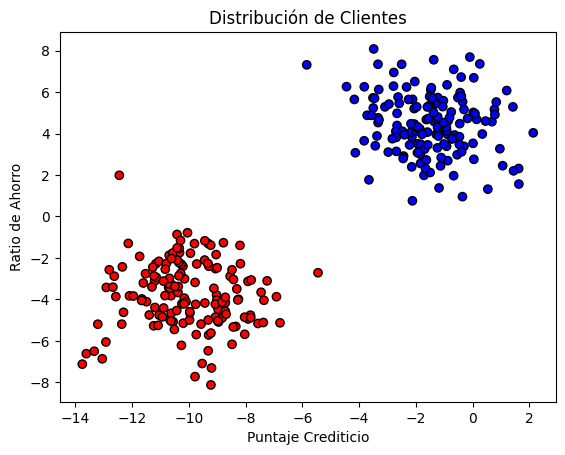

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
#Definimos el modelo secuencial.
model = Sequential([
    #Tiene capa unica que es el perceptron
    # Define la capa Dense con 1 neurona y activación 'sigmoid'
#Tiene una sola capa de salida
# input_shape=(2,): Puntaje crediticio y ahorro
    Input(shape=(2,)), Dense(units=1, activation='sigmoid')

    ])
model.summary()
# ------------------------------

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# Usa model.compile(...)
# Define el optimizer usando tf.keras.optimizers.SGD y la loss adecuada.
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), #Se puede testear/probar con un rango minimo desde 0.01 hasta un maximo de 0.5
    loss='binary_crossentropy',
    metrics=['accuracy']
)


#Por ultimo ponemos print y dentro de los () agregamos que la "Configuracion de entramiento ya esta finalizado"
print("Configuracion de entrenamiento ya esta finalizado")
# ------------------------------

Configuracion de entrenamiento ya esta finalizado


## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# history = model.fit(..., epochs=..., verbose=1)

#Definimos X_Train y despues vamos aplicando los ejemplos de la actividad en base al puntaje crediticio y ratio de ahorro

x_train= np.array([
    [0.7, 0.9], [0.3, 0.5], [0.9, 0.8], [0.4, 0.5], [0.25, 0.3], [0.45, 0.4],
    [0.85, 0.9], [0.8, 0.9], [0.1, 0.15], [0.01, 0.55]
])

#Ahora definimos los siguientes parametros:
#Estos parametros tendran las siguientes etiquetas:
# 1 = Bajo Riesgo (APROBADO), 0 = Alto Riesgo (DENEGADO)
#Definimos Y_Train
y_train= np.array([1, 1, 1, 0, 0, 0, 1, 1, 0, 0])

history = model.fit(
    x_train, y_train, epochs=50, verbose=1
    )


# ------------------------------

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.4000 - loss: 0.8333
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 0.8326
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4000 - loss: 0.8318
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 0.8311
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 0.8303
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4000 - loss: 0.8296
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4000 - loss: 0.8289
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 0.8281
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4000 - loss: 0.8274
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 0.8267
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4000 - loss: 0.8260
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4000 - loss: 0.8253


## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step


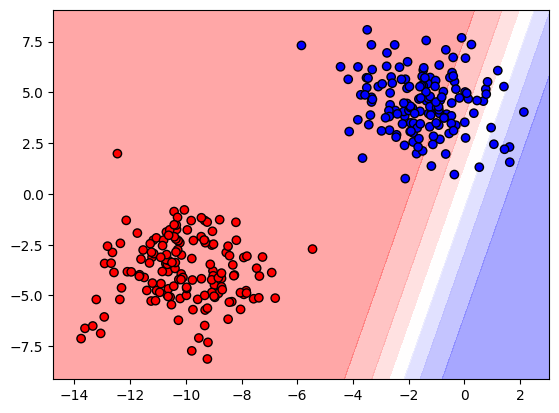

In [ ]:
#Definimos plot_frontier y a su lado entre () ponemos los ejes (x,y).

def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

#Seguimos poniendo los x,y, pero aca tendran un valor maximo(max) minimo(min)

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

In [ ]:
#Tenemos sesgos
#Ponemos variables como el peso, bias y el peso del modelo mismo
weights, bias = model.get_weights()

#Imprimimos con los nombres "Pesos de entrada" y "Valor de Bias"

print(f"Pesos de entrada: {weights}")
print(f"Valor del Bias: {bias}")

#Importamos una libreria que es from tensorflow.keras import regularizers

from tensorflow.keras import regularizers

#El modelo es secuencial

model = Sequential([
    Input(shape=(2,)),

    Dense(units=1,
          activation='sigmoid',
          kernel_regularizer=regularizers.l2(0.01))
])

Pesos de entrada: [[0.05287814]
 [0.13946092]]
Valor del Bias: [0.]
